# Spatial autocorrelation

The second domain in geostatista answers *"is this map clustered, and where?"*. The flow is:

**build a weights matrix → measure global autocorrelation → map local clusters / hotspots.**

Every statistic is a free function taking a `FeatureCollection`, a column, and a `Weights` matrix. We use a
synthetic 8×8 lattice with a north-south gradient, so we know the answer up front: strong positive
autocorrelation.

In [1]:
%matplotlib inline
import numpy as np
import geopandas as gpd
from shapely.geometry import box
from pyramids.feature import FeatureCollection
from geostatista import (
    Weights, morans_i, gearys_c, local_morans, getis_ord_gi,
    plot_lisa, plot_hotspots, spatial_autocorrelation, hotspots,
)

n = 8
polys, value = [], []
for r in range(n):
    for c in range(n):
        polys.append(box(c, r, c + 1, r + 1))
        value.append(float(r))          # value increases with the row -> a N-S gradient
tracts = FeatureCollection(gpd.GeoDataFrame({"v": value}, geometry=polys, crs="EPSG:32633"))
tracts.head()

2026-07-18 20:19:03 | INFO | pyramids.base.config | Logging is configured.


,v,geometry
0,0.0,"POLYGON ((1 0, 1 1, 0 1, 0 0, 1 0))"
1,0.0,"POLYGON ((2 0, 2 1, 1 1, 1 0, 2 0))"
2,0.0,"POLYGON ((3 0, 3 1, 2 1, 2 0, 3 0))"
3,0.0,"POLYGON ((4 0, 4 1, 3 1, 3 0, 4 0))"
4,0.0,"POLYGON ((5 0, 5 1, 4 1, 4 0, 5 0))"


## 1. Spatial weights — who is a neighbor?

Four builders cover the common definitions of adjacency. Contiguity needs polygons; k-nearest and distance-band
work off centroids.

In [2]:
w_queen = Weights.queen(tracts)                  # share a vertex OR an edge
w_rook = Weights.rook(tracts)                    # share an edge only
w_knn = Weights.knn(tracts, k=4)                 # 4 nearest centroids
w_band = Weights.distance_band(tracts, 1.5)      # neighbors within 1.5 units

for name, w in [("queen", w_queen), ("rook", w_rook), ("knn(4)", w_knn), ("band(1.5)", w_band)]:
    print(f"{name:10} n={w.n:3d}  links={int(w.cardinalities.sum()):4d}  "
          f"card min/max={w.cardinalities.min()}/{w.cardinalities.max()}")

queen      n= 64  links= 420  card min/max=3/8
rook       n= 64  links= 224  card min/max=2/4
knn(4)     n= 64  links= 256  card min/max=4/4
band(1.5)  n= 64  links= 420  card min/max=3/8


A `Weights` object exposes its neighbor structure and can be **row-standardized** (each row sums to 1) — the
transform Moran's I uses by default. Features with no neighbors are *islands* and keep a zero row.

In [3]:
print("neighbors of feature 0 (a corner):", list(w_queen.neighbors[0]))
print("cardinalities[:8] :", w_queen.cardinalities[:8])
print("islands           :", w_queen.islands)

wr = w_queen.transform("r")
print("row-standardized row 0 sums to:", round(float(wr.sparse[0].sum()), 6))

neighbors of feature 0 (a corner): [np.int64(1), np.int64(8), np.int64(9)]
cardinalities[:8] : [3 5 5 5 5 5 5 3]
islands           : []
row-standardized row 0 sums to: 1.0


## 2. Global autocorrelation — is the whole map clustered?

**Moran's I** ranges around its expectation `EI = -1/(n-1)`; values well above it mean positive autocorrelation
(nearby features are similar). **Geary's C** is the complementary statistic — its expectation is 1, and values
below 1 mean positive autocorrelation. Both carry a permutation p-value.

In [4]:
mi = morans_i(tracts, "v", w_queen, permutations=199, seed=0)
gc = gearys_c(tracts, "v", w_queen, permutations=199, seed=0)
print(mi)
print(gc)
print("Moran summary:", {k: round(v, 4) for k, v in mi.summary().items()})

<MoranResult I=0.8972 EI=-0.0159 z=13.584 p_sim=0.0050>
<GearyResult C=0.0681 EC=1 z=-13.882 p_sim=0.0050>
Moran summary: {'I': 0.8972, 'EI': -0.0159, 'z': 13.5836, 'p_norm': 0.0, 'p_sim': 0.005}


`I ≈ 0.9` with a tiny p-value confirms the strong gradient — exactly what we built in.

## 3. Local Moran (LISA) — which features cluster?

Local Moran decomposes the global statistic per feature and classifies each into a quadrant: **HH**/**LL**
clusters (a high/low value amid high/low neighbors) or **HL**/**LH** spatial outliers. Only features whose
permutation p-value clears `alpha` keep a cluster label; the rest are `ns`.

In [5]:
lisa = local_morans(tracts, "v", w_queen, permutations=199, seed=0)
lisa[["v", "local_i", "z_sim", "p_sim", "cluster"]].head()

,v,local_i,z_sim,p_sim,cluster
0,0.0,1.859375,2.166472,0.015,LL
1,0.0,1.903125,3.015365,0.010,LL
2,0.0,1.903125,3.256975,0.005,LL
3,0.0,1.903125,2.918601,0.005,LL
4,0.0,1.903125,2.874089,0.005,LL


In [6]:
lisa["cluster"].value_counts()

cluster
HH    23
LL    21
ns    20
Name: count, dtype: int64

Map the clusters (needs the `viz` extra). The top rows come out **HH**, the bottom rows **LL**, with a neutral
band through the middle of the gradient.

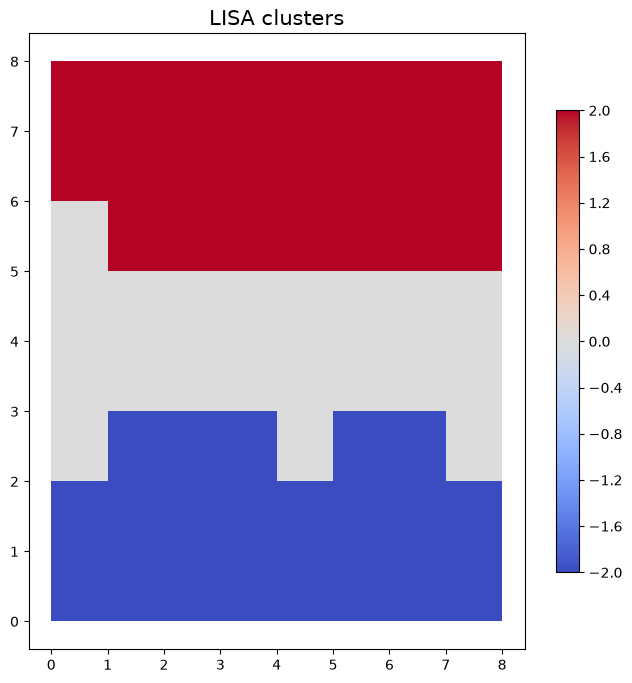

In [7]:
fig, ax = plot_lisa(lisa)

## 4. Getis-Ord Gi* — hot and cold spots

Where LISA finds clusters *and* outliers, the Getis-Ord Gi* statistic asks a simpler question: is this feature
surrounded by unusually **high** (hot) or **low** (cold) values? It annotates `gi`, `z`, `p`, and a `hotspot`
label.

In [8]:
hot = getis_ord_gi(tracts, "v", w_queen, star=True)
hot[["v", "gi", "z", "p", "hotspot"]].head()

,v,gi,z,p,hotspot
0,0.0,0.008929,-2.683282,0.00729,cold
1,0.0,0.013393,-3.342516,0.00083,cold
2,0.0,0.013393,-3.342516,0.00083,cold
3,0.0,0.013393,-3.342516,0.00083,cold
4,0.0,0.013393,-3.342516,0.00083,cold


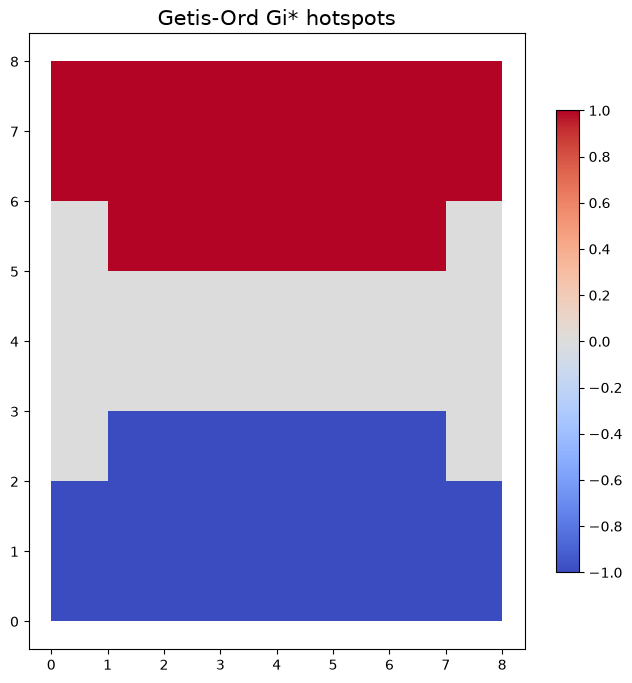

In [9]:
fig, ax = plot_hotspots(hot)

## 5. The one-call facade

For the common case, `spatial_autocorrelation` and `hotspots` wrap the whole thing — pass a weights *name* and get
back a plain dict / annotated `FeatureCollection`.

In [10]:
print(spatial_autocorrelation(tracts, "v", weights="queen", seed=0))

hot2 = hotspots(tracts, "v", weights="queen")
print("hotspot classes:", dict(hot2["hotspot"].value_counts()))

{'I': 0.8972222222222225, 'EI': -0.015873015873015872, 'z': 13.58364194952992, 'p': 0.0, 'n': 64, 'weights': 'b'}
hotspot classes: {'cold': np.int64(22), 'hot': np.int64(22), 'ns': np.int64(20)}


That completes the autocorrelation surface: **weights → global (Moran / Geary) → local (LISA / Gi*) → maps**,
plus the one-call facade. Pair it with the [kriging workflow](01_kriging_workflow.ipynb) for the interpolation
half of the package.